In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [33]:

# Load the dataset
data = pd.read_csv("C:\\Users\\germa\\Downloads\\RF_windowed.csv")  # Replace with your actual file path

# Split features and target
X = data[["x_mean","y_mean","z_mean","t_mean","x_std","y_std","z_std","t_std","x_sum","y_sum","z_sum","t_sum","x_median","y_median","z_median","t_median"]]  # Replace 'label' with your actual target column name
#X = data.drop(columns="Label")
y = data["Label"]  # Replace 'label' with your actual target column name

print(X.head())  # Inspect the features
print(y.head())  # Inspect the target


      x_mean       y_mean     z_mean    t_mean        x_std        y_std  \
0   2.797753 -1007.883146  -8.098876  0.109045  1714.420730  1180.965029   
1  -3.191011  -985.062921  15.384270  0.329998  1777.761784  1148.892403   
2  -3.815730  -996.658427   4.164045  0.546524  1850.650938  1231.264912   
3 -22.644944 -1001.017978   3.584270  0.767537  1743.957604  1196.155499   
4   4.274157 -1002.067416  -5.496629  0.987674  1647.763377  1360.425768   

         z_std     t_std    x_sum     y_sum   z_sum    t_sum  x_median  \
0  1387.944095  0.063545   1245.0 -448508.0 -3604.0   48.525      62.0   
1  1375.068519  0.063237  -1420.0 -438353.0  6846.0  146.849     -23.0   
2  1393.358803  0.062419  -1698.0 -443513.0  1853.0  243.203     105.0   
3  1419.261094  0.064790 -10077.0 -445453.0  1595.0  341.554      21.0   
4  1357.289538  0.063358   1902.0 -445920.0 -2446.0  439.515     107.0   

   y_median  z_median  t_median  
0   -1106.0      27.0     0.108  
1   -1011.0      95.0     0.32

In [35]:

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Training data shape: (14407, 16)
Test data shape: (3602, 16)


In [37]:

# Create a pipeline
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # Handle missing values
    ('scaler', StandardScaler()),  # Scale features
    ('classifier', RandomForestClassifier(random_state=42))  # Train Random Forest
])


In [39]:

# Train the pipeline
pipeline.fit(X_train, y_train)

# Test the pipeline
y_pred = pipeline.predict(X_test)

# Evaluate the performance
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1444
           1       1.00      1.00      1.00      2158

    accuracy                           1.00      3602
   macro avg       1.00      1.00      1.00      3602
weighted avg       1.00      1.00      1.00      3602



In [41]:

# Define hyperparameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10]
}

# Perform Grid Search with Cross-Validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Print the best parameters and test accuracy
print("Best Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2f}")

# Test with the best estimator
y_pred = grid_search.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))


Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best Cross-Validation Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1444
           1       1.00      1.00      1.00      2158

    accuracy                           1.00      3602
   macro avg       1.00      1.00      1.00      3602
weighted avg       1.00      1.00      1.00      3602



In [42]:

# Save the pipeline
joblib.dump(pipeline, "tool_classification_pipeline.pkl")

# Load the pipeline
#loaded_pipeline = joblib.load("tool_classification_pipeline.pkl")

# Use the loaded pipeline for predictions
#y_pred = loaded_pipeline.predict(X_test)
#print(classification_report(y_test, y_pred))


['tool_classification_pipeline.pkl']

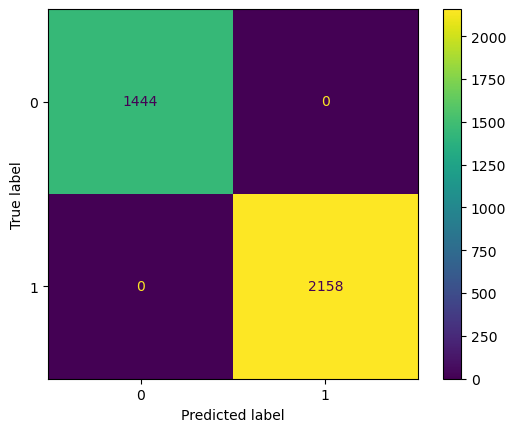

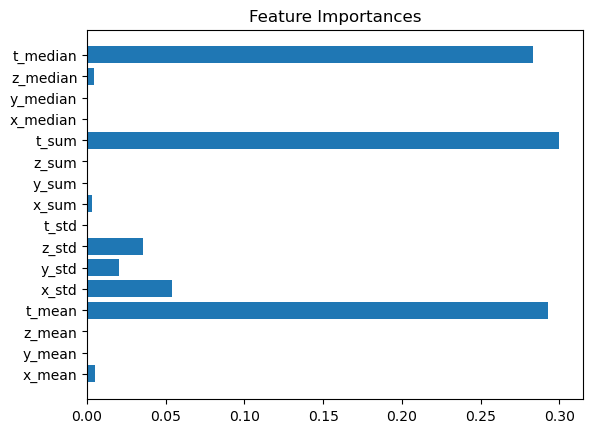

In [43]:

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# Feature importance (for Random Forest)
feature_importances = pipeline.named_steps['classifier'].feature_importances_
plt.barh(X.columns, feature_importances)
plt.title("Feature Importances")
plt.show()
